In [17]:
# ------------------------------------------------------------
#  STEP 1: Import Required Libraries
# ------------------------------------------------------------
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import seaborn as sns

In [18]:
# ------------------------------------------------------------
#  STEP 2: Define Dataset Path
# ------------------------------------------------------------
# Make sure your folder structure is like:
# AI DISEASE PREDICTION/
# └── Dataset_BUSI_with_GT/
#     ├── benign/
#     ├── malignant/
#     └── normal/

data_dir = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT"

categories = ['benign', 'malignant', 'normal']
img_size = 128   # Resize all images to 128x128 for uniformity

In [19]:
# ------------------------------------------------------------
#  STEP 3: Load and Preprocess Images
# ------------------------------------------------------------
data = []
labels = []

for category in categories:
    path = os.path.join(data_dir, category)
    label = categories.index(category)  # 0, 1, 2

    for img_file in os.listdir(path):
        if img_file.endswith(".png"):
            img_path = os.path.join(path, img_file)
            try:
                # Read the image in grayscale (SVM works on features, not colors)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (img_size, img_size))

                # Flatten the image to 1D vector
                img_flatten = img.flatten()

                data.append(img_flatten)
                labels.append(label)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")

data = np.array(data)
labels = np.array(labels)

print(" Data Loaded Successfully!")
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

 Data Loaded Successfully!
Data shape: (2531, 16384)
Labels shape: (2531,)


In [20]:
# ------------------------------------------------------------
#  STEP 4: Data Normalization and Splitting
# ------------------------------------------------------------
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

X_train, X_test, y_train, y_test = train_test_split(
    data_scaled, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 2024, Testing samples: 507


In [21]:
# ------------------------------------------------------------
#  STEP 5: Train SVM Model
# ------------------------------------------------------------
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

print(" SVM Model Trained Successfully!")

 SVM Model Trained Successfully!



 Model Accuracy: 79.88%

Classification Report:
               precision    recall  f1-score   support

      benign       0.77      0.68      0.72       178
   malignant       0.80      0.80      0.80       169
      normal       0.82      0.93      0.87       160

    accuracy                           0.80       507
   macro avg       0.80      0.80      0.80       507
weighted avg       0.80      0.80      0.80       507



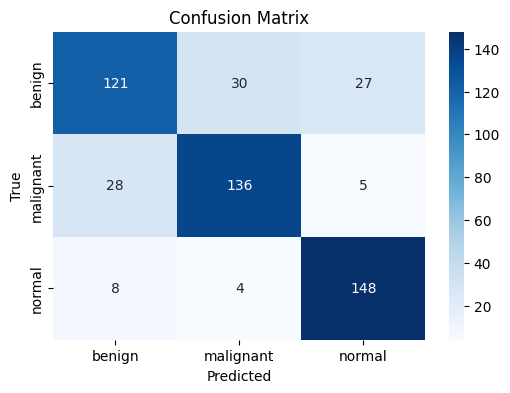

In [22]:
# ------------------------------------------------------------
#  STEP 6: Evaluate the Model
# ------------------------------------------------------------
y_pred = svm_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n Model Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=categories))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [23]:
# ------------------------------------------------------------
#  STEP 7: Save the Trained Model and Scaler
# ------------------------------------------------------------
import os
import joblib

# Create the folder if it doesn't exist
os.makedirs("model", exist_ok=True)

# Define file paths
model_path = "model/breast_cancer_svm_model.pkl"
scaler_path = "model/scaler.pkl"

# Save the trained SVM model
joblib.dump(svm_model, model_path)
print(f"Model Saved at: {model_path}")

# Save the fitted scaler (used during training)
joblib.dump(scaler, scaler_path)
print(f" Scaler Saved at: {scaler_path}")


Model Saved at: model/breast_cancer_svm_model.pkl
 Scaler Saved at: model/scaler.pkl


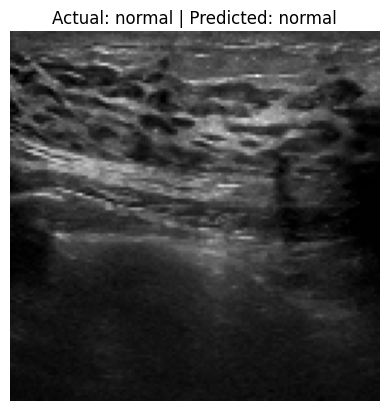

In [31]:
#  STEP 8: Test Prediction on a Random Image
# ------------------------------------------------------------
import random

random_category = random.choice(categories)
random_path = os.path.join(data_dir, random_category)
random_img = random.choice(os.listdir(random_path))

img_path = os.path.join(random_path, random_img)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (img_size, img_size))
img_flatten = img_resized.flatten().reshape(1, -1)
img_scaled = scaler.transform(img_flatten)

pred = svm_model.predict(img_scaled)[0]
predicted_label = categories[pred]

plt.imshow(img_resized, cmap='gray')
plt.title(f"Actual: {random_category} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()


 Prediction Result
────────────────────────────
Image Path     : C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT\normal\normal (2).png
Predicted Class: Normal
─────────────────────────────


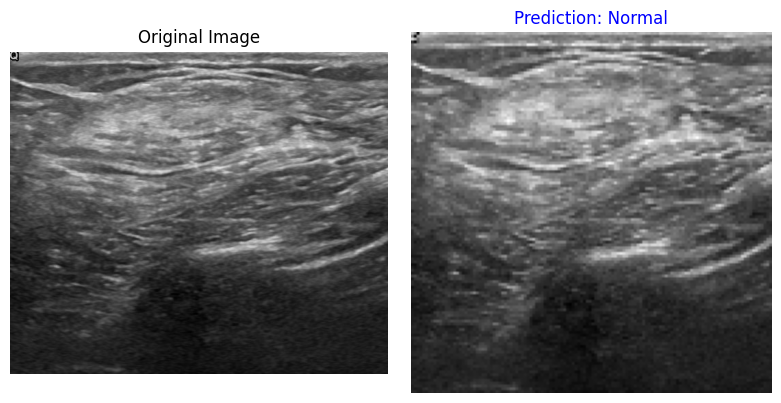

 Prediction completed successfully!


In [30]:
# ==============================================================
#  BREAST CANCER IMAGE PREDICTION USING TRAINED SVM MODEL
# (Now displays both original and preprocessed images)
# ==============================================================

import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

#  Step 1: Ask the user to input the image path
image_path = input("📸 Enter the full path of the image to predict: ").strip()

#  Step 2: Load the trained SVM model and scaler
model_path = "model/breast_cancer_svm_model.pkl"
scaler_path = "model/scaler.pkl"

if not os.path.exists(model_path):
    raise FileNotFoundError(" Model file not found! Check path: 'model/breast_cancer_svm_model.pkl'")

if not os.path.exists(scaler_path):
    raise FileNotFoundError(" Scaler file not found! Check path: 'model/scaler.pkl'")

model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

#  Step 3: Validate image path
if not os.path.exists(image_path):
    raise FileNotFoundError(f" Image not found at: {image_path}")

#  Step 4: Read and preprocess the image
original_img = cv2.imread(image_path)  # Keep original (colored)
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
img_resized = cv2.resize(gray_img, (128, 128))  # Resize same as training
img_flatten = img_resized.flatten().reshape(1, -1)
img_scaled = scaler.transform(img_flatten)

#  Step 5: Make prediction
prediction = model.predict(img_scaled)[0]

#  Step 6: Map numeric labels to class names
class_labels = {0: "Benign", 1: "Malignant", 2: "Normal"}
predicted_label = class_labels.get(prediction, "Unknown")

#  Step 7: Print results
print("\n Prediction Result")
print("────────────────────────────")
print(f"Image Path     : {image_path}")
print(f"Predicted Class: {predicted_label}")
print("─────────────────────────────")

#  Step 8: Display original and processed images side by side
plt.figure(figsize=(8, 4))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image", fontsize=12)
plt.axis('off')

# Resized (model input) grayscale image with prediction
plt.subplot(1, 2, 2)
plt.imshow(img_resized, cmap='gray')
plt.title(f"Prediction: {predicted_label}", fontsize=12, color='blue')
plt.axis('off')

plt.tight_layout()
plt.show()

print(" Prediction completed successfully!")


 Model Accuracy: 89.60%

 Classification Report:
              precision    recall  f1-score   support

      benign       0.85      0.86      0.85       180
   malignant       0.93      0.88      0.91       208
      normal       0.91      0.94      0.92       208

    accuracy                           0.90       596
   macro avg       0.89      0.89      0.89       596
weighted avg       0.90      0.90      0.90       596



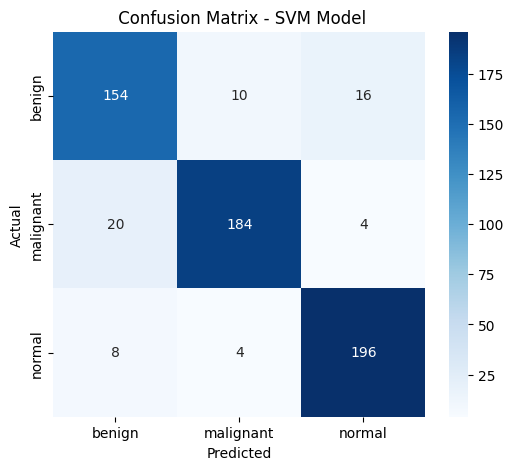

In [26]:
# ==============================================================
# SVM MODEL ACCURACY EVALUATION ON TEST DATASET
# ==============================================================

import os
import cv2
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#  Step 1: Define paths
test_dir = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\test"
model_path = "model/breast_cancer_svm_model.pkl"
scaler_path = "model/scaler.pkl"

#  Step 2: Load trained model and scaler
model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

#  Step 3: Define label mapping
class_labels = {"benign": 0, "malignant": 1, "normal": 2}
reverse_labels = {0: "Benign", 1: "Malignant", 2: "Normal"}

#  Step 4: Load all test images
X_test = []
y_test = []

for label_name, label_id in class_labels.items():
    folder = os.path.join(test_dir, label_name)
    if not os.path.exists(folder):
        print(f" Folder not found: {folder}")
        continue

    for file in os.listdir(folder):
        if file.lower().endswith(".png"):
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img_resized = cv2.resize(img, (128, 128))
            X_test.append(img_resized.flatten())
            y_test.append(label_id)

#  Step 5: Convert to arrays and scale
X_test = np.array(X_test)
y_test = np.array(y_test)
X_test_scaled = scaler.transform(X_test)

#  Step 6: Predict
y_pred = model.predict(X_test_scaled)

#  Step 7: Evaluate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(" Model Accuracy: {:.2f}%".format(accuracy * 100))

#  Step 8: Detailed Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=list(class_labels.keys())))

#  Step 9: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=list(class_labels.keys()), 
            yticklabels=list(class_labels.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(" Confusion Matrix - SVM Model")
plt.show()


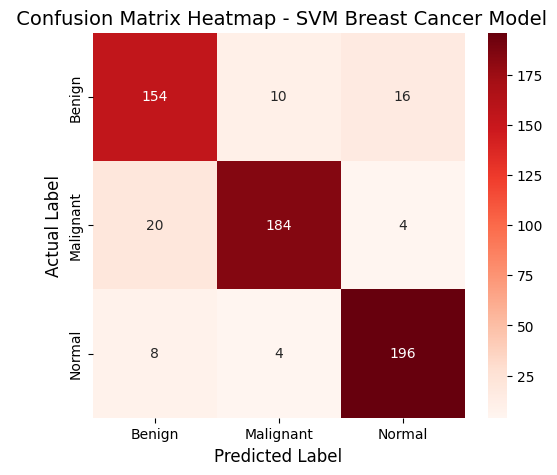


 Classification Report:
              precision    recall  f1-score   support

      benign       0.85      0.86      0.85       180
   malignant       0.93      0.88      0.91       208
      normal       0.91      0.94      0.92       208

    accuracy                           0.90       596
   macro avg       0.89      0.89      0.89       596
weighted avg       0.90      0.90      0.90       596



In [27]:
# ==============================================================
#  CONFUSION MATRIX HEATMAP FOR SVM MODEL
# ==============================================================

import os
import cv2
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

#  Step 1: Define paths
test_dir = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\test"
model_path = "model/breast_cancer_svm_model.pkl"
scaler_path = "model/scaler.pkl"

#  Step 2: Load trained model and scaler
model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

#  Step 3: Define class labels
class_labels = {"benign": 0, "malignant": 1, "normal": 2}
reverse_labels = {v: k.capitalize() for k, v in class_labels.items()}

#  Step 4: Load test images
X_test, y_test = [], []

for label_name, label_id in class_labels.items():
    folder_path = os.path.join(test_dir, label_name)
    if not os.path.exists(folder_path):
        print(f" Folder not found: {folder_path}")
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith(".png"):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img_resized = cv2.resize(img, (128, 128))
            X_test.append(img_resized.flatten())
            y_test.append(label_id)

#  Step 5: Convert and scale
X_test = np.array(X_test)
y_test = np.array(y_test)
X_test_scaled = scaler.transform(X_test)

#  Step 6: Predict
y_pred = model.predict(X_test_scaled)

#  Step 7: Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

#  Step 8: Plot Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=list(reverse_labels.values()),
            yticklabels=list(reverse_labels.values()))
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title(" Confusion Matrix Heatmap - SVM Breast Cancer Model", fontsize=14)
plt.show()

#  Step 9: Optional - Print Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=list(class_labels.keys())))
